# CMMD Breast Regions

Visualize breast bounding boxes from `CMMD_breast_region_fixed.csv` overlaid on the corresponding DICOM images.

In [1]:
import ast
import csv
import random
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, str(Path.cwd().parent))

from src.preprocessing import load_dicom_pixels

# CMMD dataset root directory
CMMD_ROOT = Path.home() / 'Escritorio/Datasets/CMMD'
CMMD_CSV = CMMD_ROOT / 'CMMD_breast_region_fixed.csv'

In [2]:
# Load CSV into a list of dicts
with CMMD_CSV.open(newline='', encoding='utf-8') as f:
    records = list(csv.DictReader(f))

print(f"Total annotations: {len(records)}")
print("Sample row:", records[0])

Total annotations: 5202
Sample row: {'file_name': 'cmmd/D1-0001/79377/70244/608a073d-14ef-455b-be5d-f73f553b97f0.dcm', 'bboxes': '[1325.429443359375, 406.74835205078125, 1924.5091552734375, 2109.11279296875]', 'scores': '0.98611134'}


In [3]:
def show_dicom_with_bbox(record, cmmd_root=CMMD_ROOT, ax=None):
    """Display a DICOM image with its breast bounding box.

    Parameters
    ----------
    record : dict
        Row from CMMD_breast_region_fixed.csv with 'file_name' and 'bboxes'.
    cmmd_root : Path, optional
        Root directory of the CMMD dataset. Defaults to CMMD_ROOT.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on. If None, a new figure is created.
    """
    # Build full path from relative path in CSV
    path = Path(cmmd_root) / record['file_name']
    # bboxes format: [x1, y1, x2, y2]
    x1, y1, x2, y2 = ast.literal_eval(record['bboxes'])
    score = float(record['scores'])

    pixels = load_dicom_pixels(path, normalize=True)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 8))

    ax.imshow(pixels, cmap='gray', aspect='equal')

    rect = mpatches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor='lime', facecolor='none',
        label=f'breast (score={score:.3f})'
    )
    ax.add_patch(rect)
    ax.legend(loc='upper right', fontsize=8)
    ax.set_title(path.stem, fontsize=8)
    ax.axis('off')
    return ax

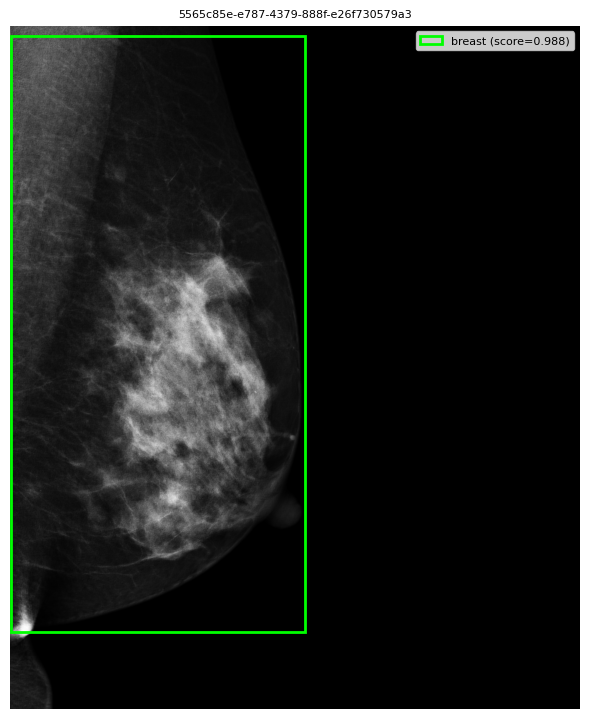

In [4]:
# Show a single random example
record = random.choice(records)
show_dicom_with_bbox(record)
plt.tight_layout()
plt.show()

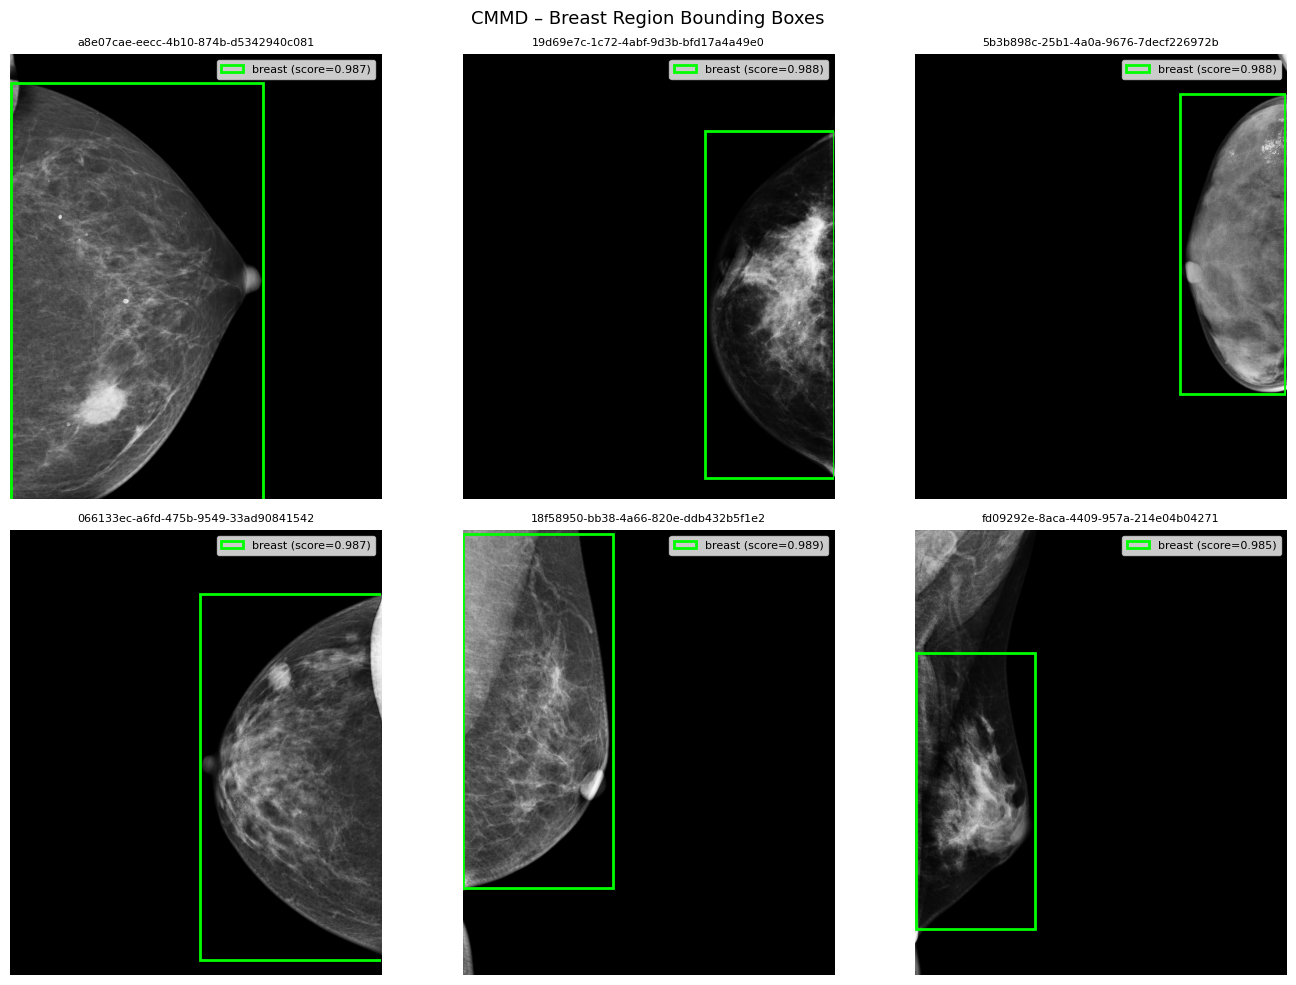

In [5]:
# Show a 2×3 grid of random examples
sample = random.sample(records, 6)
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
for ax, rec in zip(axes.flat, sample):
    show_dicom_with_bbox(rec, ax=ax)
plt.suptitle('CMMD – Breast Region Bounding Boxes', fontsize=13)
plt.tight_layout()
plt.show()

Found 2 annotations for D1-0091


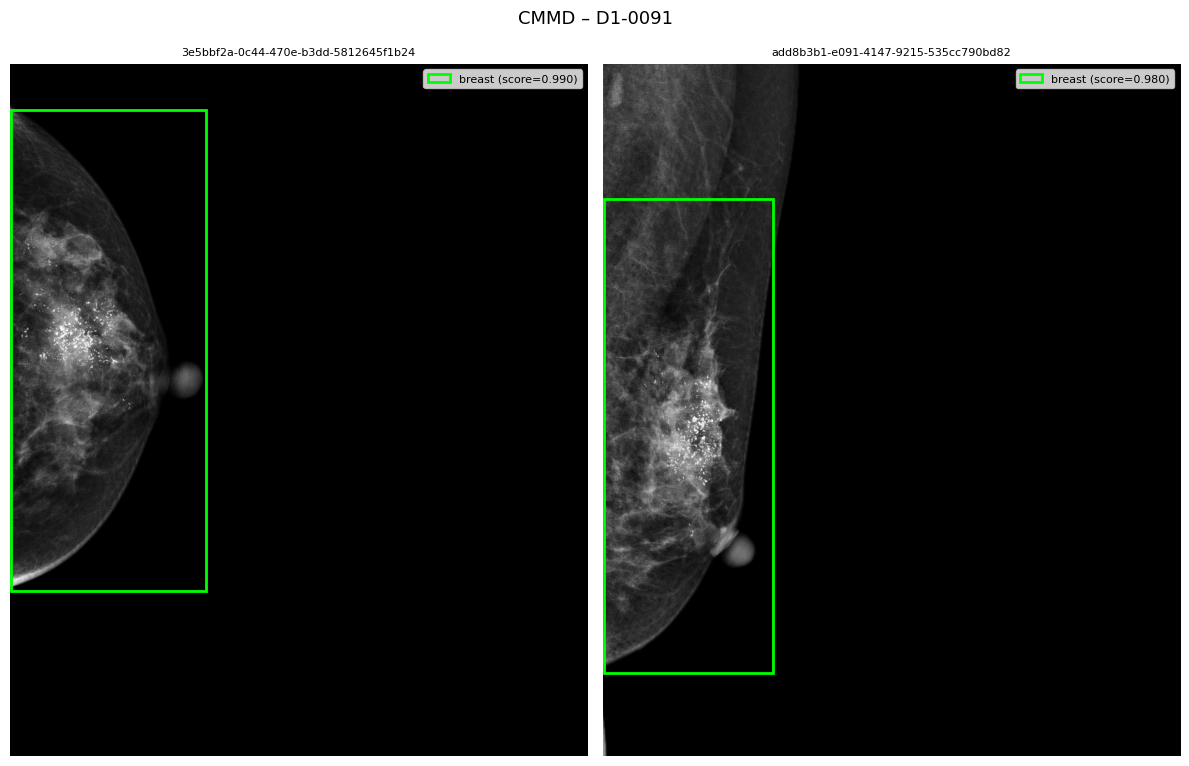

In [8]:
# Show a specific case by index or case ID
CASE_ID = 'D1-0091'  # change as needed

case_records = [r for r in records if CASE_ID in r['file_name']]
print(f"Found {len(case_records)} annotations for {CASE_ID}")

if case_records:
    n = len(case_records)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 8))
    if n == 1:
        axes = [axes]
    for ax, rec in zip(axes, case_records):
        show_dicom_with_bbox(rec, ax=ax)
    plt.suptitle(f'CMMD – {CASE_ID}', fontsize=13)
    plt.tight_layout()
    plt.show()